# Support Vector Machines and Kernel Methods

This notebook covers SVM fundamentals, the kernel trick, SVR, and algorithm comparisons.

📺 **Video Lecture:** [https://youtu.be/tmCPYgbE-vk](https://youtu.be/tmCPYgbE-vk)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Linear SVM with Margin Visualization

Linear SVM finds the maximum-margin hyperplane separating two classes.

Linear SVM Accuracy: 1.0000
Support Vectors: 4


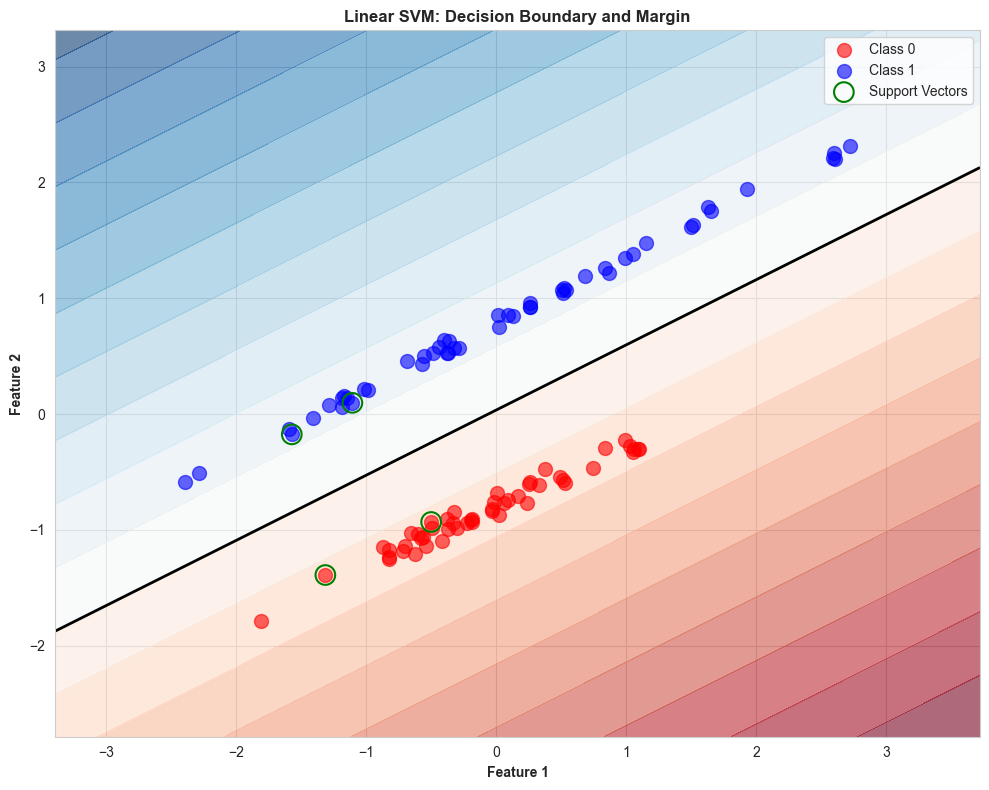

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_scaled = StandardScaler().fit_transform(X)
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_scaled, y)
print(f'Linear SVM Accuracy: {svm_linear.score(X_scaled, y):.4f}')
print(f'Support Vectors: {len(svm_linear.support_vectors_)}')
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 100),
                      np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 100))
Z = svm_linear.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
plt.scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='red', label='Class 0', alpha=0.6, s=100)
plt.scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='blue', label='Class 1', alpha=0.6, s=100)
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], s=200, linewidth=1.5, facecolors='none', edgecolors='green', label='Support Vectors')
plt.xlabel('Feature 1', fontweight='bold')
plt.ylabel('Feature 2', fontweight='bold')
plt.title('Linear SVM: Decision Boundary and Margin', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Effect of C Parameter

C controls the trade-off between margin width and classification error. Larger C: less regularization, more overfitting.

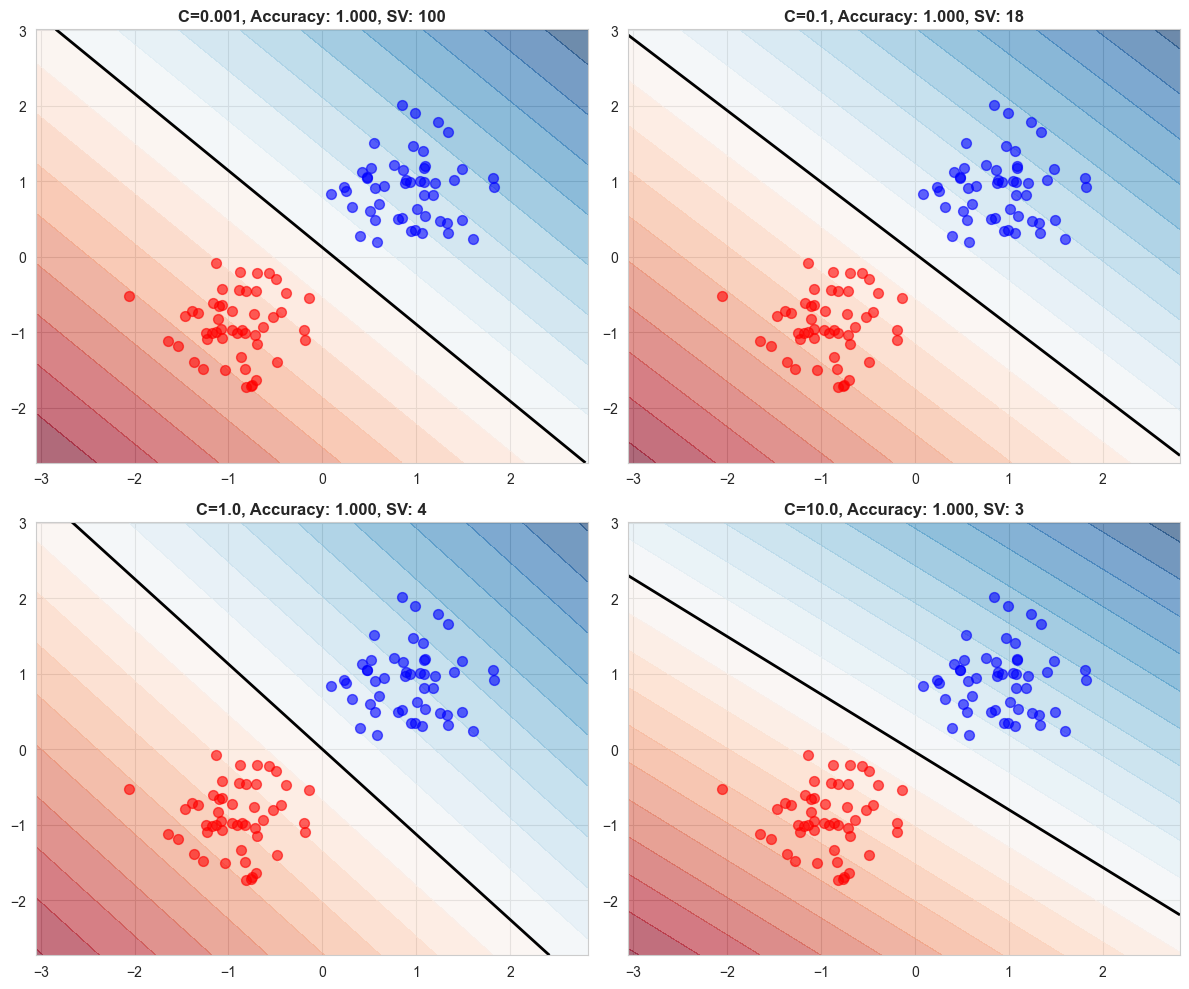

In [3]:
np.random.seed(42)
X_overlap = np.vstack([np.random.randn(50, 2) - [2, 2], np.random.randn(50, 2) + [2, 2]])
y_overlap = np.hstack([np.zeros(50), np.ones(50)])
X_overlap_scaled = StandardScaler().fit_transform(X_overlap)
C_values = [0.001, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for idx, C in enumerate(C_values):
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_overlap_scaled, y_overlap)
    xx, yy = np.meshgrid(np.linspace(X_overlap_scaled[:, 0].min() - 1, X_overlap_scaled[:, 0].max() + 1, 100),
                          np.linspace(X_overlap_scaled[:, 1].min() - 1, X_overlap_scaled[:, 1].max() + 1, 100))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    axes[idx].contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    axes[idx].scatter(X_overlap_scaled[y_overlap==0, 0], X_overlap_scaled[y_overlap==0, 1], c='red', alpha=0.6, s=50)
    axes[idx].scatter(X_overlap_scaled[y_overlap==1, 0], X_overlap_scaled[y_overlap==1, 1], c='blue', alpha=0.6, s=50)
    acc = svm.score(X_overlap_scaled, y_overlap)
    axes[idx].set_title(f'C={C}, Accuracy: {acc:.3f}, SV: {len(svm.support_vectors_)}', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Kernel Trick: Linear vs RBF vs Polynomial

Kernels enable SVMs to handle non-linear boundaries without explicit feature transformation.

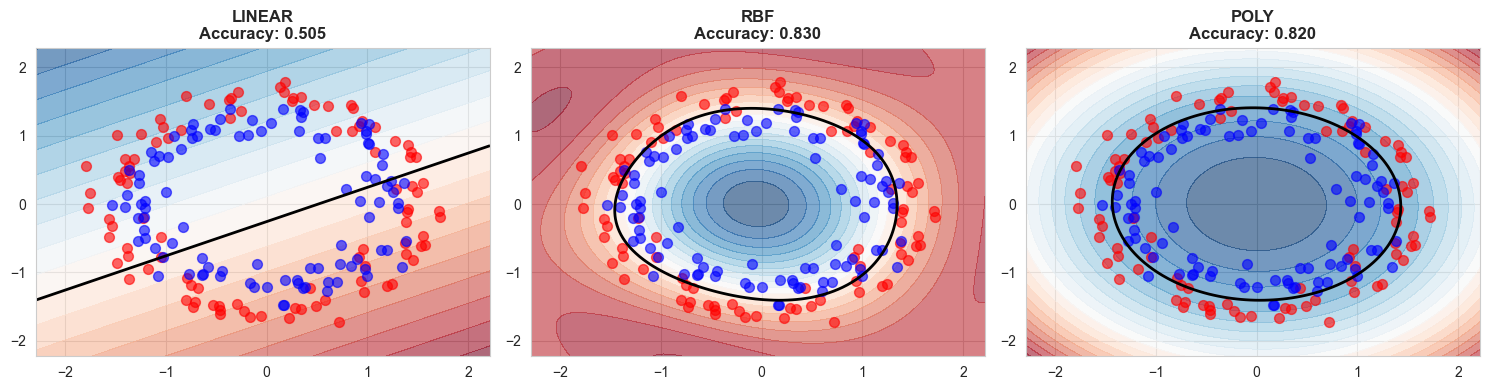

In [4]:
X_circle, y_circle = make_circles(n_samples=200, noise=0.1, random_state=42)
X_circle_scaled = StandardScaler().fit_transform(X_circle)
kernels = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, kernel in enumerate(kernels):
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=2, C=1.0, random_state=42)
    else:
        svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    svm.fit(X_circle_scaled, y_circle)
    xx, yy = np.meshgrid(np.linspace(X_circle_scaled[:, 0].min() - 0.5, X_circle_scaled[:, 0].max() + 0.5, 100),
                          np.linspace(X_circle_scaled[:, 1].min() - 0.5, X_circle_scaled[:, 1].max() + 0.5, 100))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    axes[idx].contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    axes[idx].scatter(X_circle_scaled[y_circle==0, 0], X_circle_scaled[y_circle==0, 1], c='red', alpha=0.6, s=50)
    axes[idx].scatter(X_circle_scaled[y_circle==1, 0], X_circle_scaled[y_circle==1, 1], c='blue', alpha=0.6, s=50)
    acc = svm.score(X_circle_scaled, y_circle)
    axes[idx].set_title(f'{kernel.upper()}\nAccuracy: {acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Gamma Parameter Effect in RBF Kernel

Gamma controls the influence of each training example. Low gamma = global influence, high gamma = local.

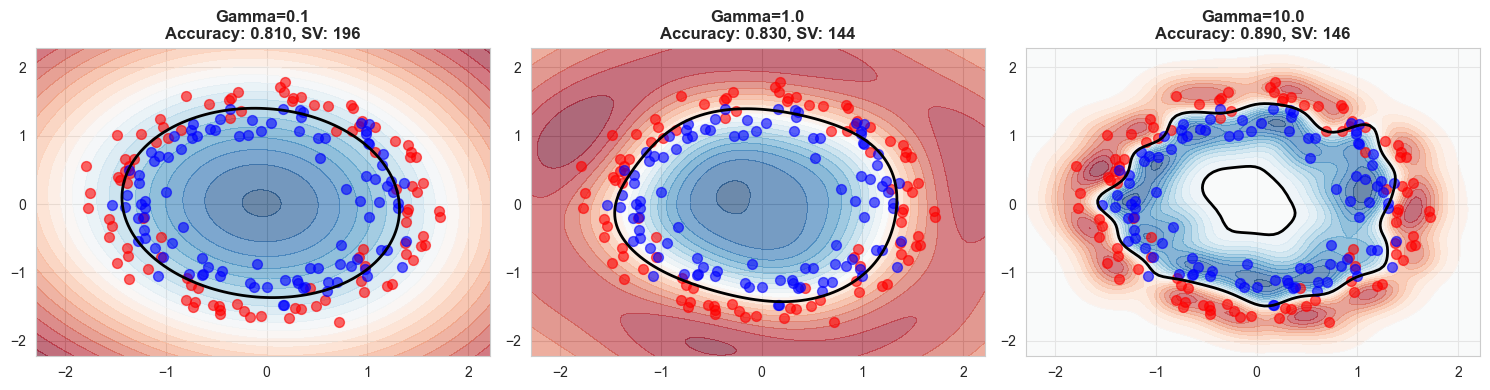

In [5]:
gamma_vals = [0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, gamma in enumerate(gamma_vals):
    svm = SVC(kernel='rbf', C=1.0, gamma=gamma, random_state=42)
    svm.fit(X_circle_scaled, y_circle)
    xx, yy = np.meshgrid(np.linspace(X_circle_scaled[:, 0].min() - 0.5, X_circle_scaled[:, 0].max() + 0.5, 100),
                          np.linspace(X_circle_scaled[:, 1].min() - 0.5, X_circle_scaled[:, 1].max() + 0.5, 100))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    axes[idx].contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    axes[idx].scatter(X_circle_scaled[y_circle==0, 0], X_circle_scaled[y_circle==0, 1], c='red', alpha=0.6, s=50)
    axes[idx].scatter(X_circle_scaled[y_circle==1, 0], X_circle_scaled[y_circle==1, 1], c='blue', alpha=0.6, s=50)
    acc = svm.score(X_circle_scaled, y_circle)
    n_sv = len(svm.support_vectors_)
    axes[idx].set_title(f'Gamma={gamma}\nAccuracy: {acc:.3f}, SV: {n_sv}', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Support Vector Identification

Support vectors are critical training points closest to the decision boundary.

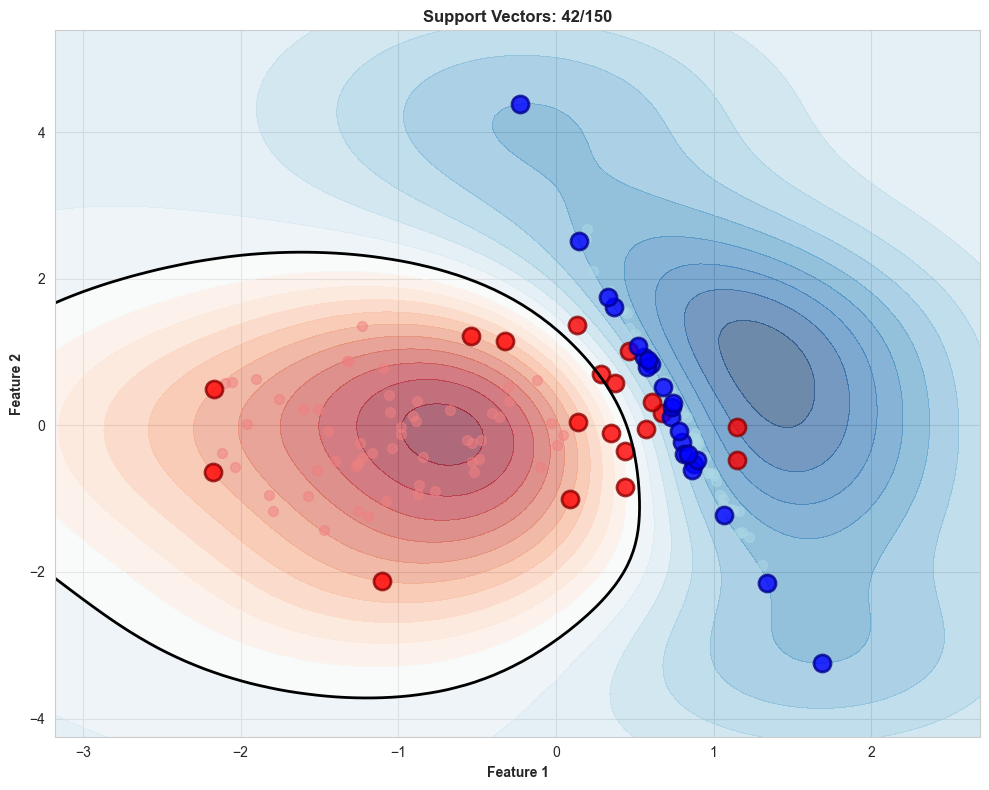

Total SV: 42
Percentage: 28.0%


In [6]:
X_plot, y_plot = make_classification(n_samples=150, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_plot_scaled = StandardScaler().fit_transform(X_plot)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_plot_scaled, y_plot)
fig, ax = plt.subplots(figsize=(10, 8))
xx, yy = np.meshgrid(np.linspace(X_plot_scaled[:, 0].min() - 1, X_plot_scaled[:, 0].max() + 1, 100),
                      np.linspace(X_plot_scaled[:, 1].min() - 1, X_plot_scaled[:, 1].max() + 1, 100))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
is_support = np.isin(np.arange(len(X_plot_scaled)), svm.support_)
ax.scatter(X_plot_scaled[~is_support & (y_plot==0), 0], X_plot_scaled[~is_support & (y_plot==0), 1], c='lightcoral', alpha=0.5, s=50)
ax.scatter(X_plot_scaled[~is_support & (y_plot==1), 0], X_plot_scaled[~is_support & (y_plot==1), 1], c='lightblue', alpha=0.5, s=50)
ax.scatter(X_plot_scaled[is_support & (y_plot==0), 0], X_plot_scaled[is_support & (y_plot==0), 1], c='red', alpha=0.8, s=150, edgecolors='darkred', linewidth=2)
ax.scatter(X_plot_scaled[is_support & (y_plot==1), 0], X_plot_scaled[is_support & (y_plot==1), 1], c='blue', alpha=0.8, s=150, edgecolors='darkblue', linewidth=2)
ax.set_xlabel('Feature 1', fontweight='bold')
ax.set_ylabel('Feature 2', fontweight='bold')
ax.set_title(f'Support Vectors: {len(svm.support_)}/{len(X_plot_scaled)}', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total SV: {len(svm.support_)}')
print(f'Percentage: {len(svm.support_)/len(X_plot_scaled)*100:.1f}%')

## 6. SVM vs Logistic Regression

Both are large-margin classifiers but use different regularization and loss functions.

                 Model  Train Acc  Test Acc
0            SVM (RBF)   0.828571  0.733333
1  Logistic Regression   0.535714  0.383333


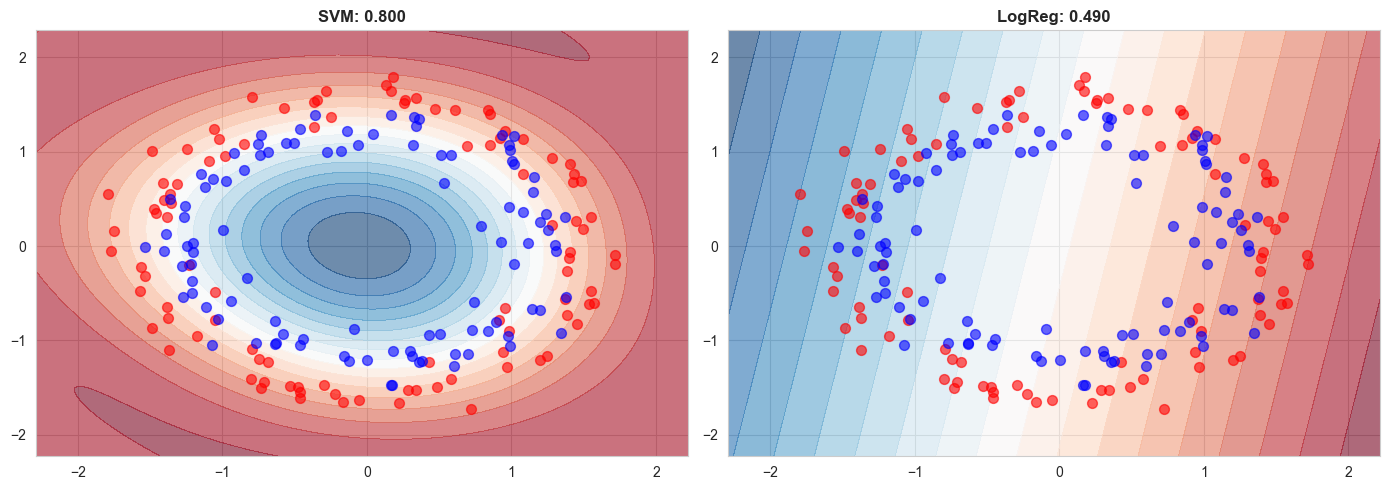

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_circle_scaled, y_circle, test_size=0.3, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
comparison = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Logistic Regression'],
    'Train Acc': [svm.score(X_train, y_train), lr.score(X_train, y_train)],
    'Test Acc': [svm.score(X_test, y_test), lr.score(X_test, y_test)]
})
print(comparison)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (model, name) in enumerate([(svm, 'SVM'), (lr, 'LogReg')]):
    xx, yy = np.meshgrid(np.linspace(X_circle_scaled[:, 0].min() - 0.5, X_circle_scaled[:, 0].max() + 0.5, 100),
                          np.linspace(X_circle_scaled[:, 1].min() - 0.5, X_circle_scaled[:, 1].max() + 0.5, 100))
    if hasattr(model, 'decision_function'):
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    else:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
    axes[idx].scatter(X_circle_scaled[y_circle==0, 0], X_circle_scaled[y_circle==0, 1], c='red', alpha=0.6, s=50)
    axes[idx].scatter(X_circle_scaled[y_circle==1, 0], X_circle_scaled[y_circle==1, 1], c='blue', alpha=0.6, s=50)
    acc = model.score(X_circle_scaled, y_circle)
    axes[idx].set_title(f'{name}: {acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Support Vector Regression (SVR)

SVR applies SVM principles to regression with epsilon-insensitive loss.

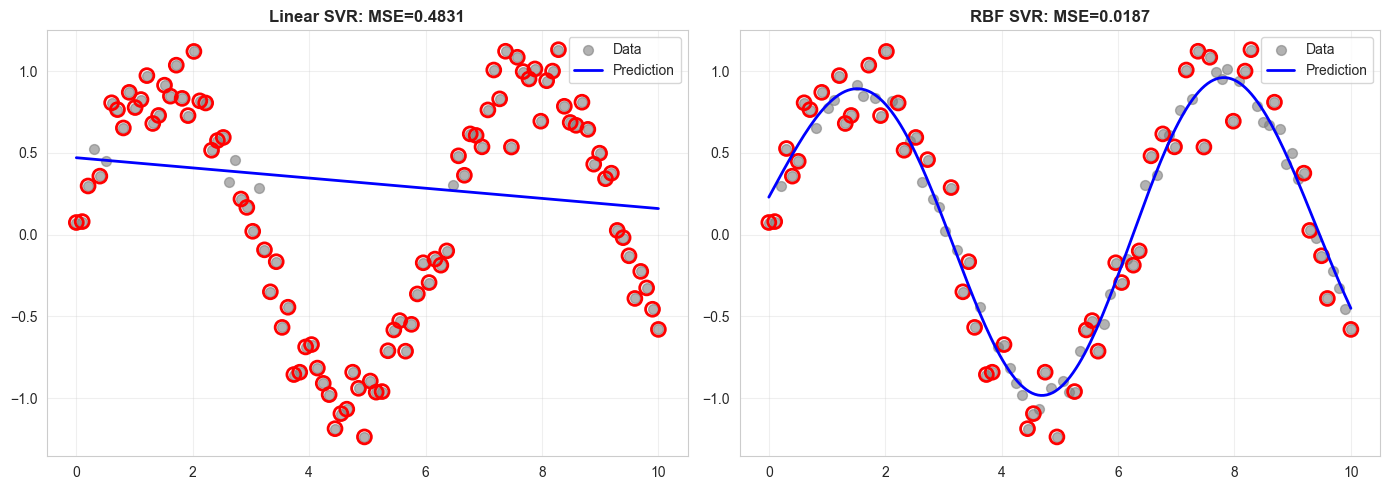

In [8]:
np.random.seed(42)
X_reg = np.linspace(0, 10, 100).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.15, 100)
svr_linear = SVR(kernel='linear', C=1.0)
svr_rbf = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_linear.fit(X_reg, y_reg)
svr_rbf.fit(X_reg, y_reg)
X_plot_reg = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred_linear = svr_linear.predict(X_plot_reg)
y_pred_rbf = svr_rbf.predict(X_plot_reg)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (y_pred, model, name) in enumerate([(y_pred_linear, svr_linear, 'Linear'), (y_pred_rbf, svr_rbf, 'RBF')]):
    axes[idx].scatter(X_reg, y_reg, alpha=0.6, s=50, color='gray', label='Data')
    axes[idx].plot(X_plot_reg, y_pred, 'b-', linewidth=2, label='Prediction')
    axes[idx].scatter(X_reg[model.support_], y_reg[model.support_], s=100, linewidth=2, facecolors='none', edgecolors='red')
    mse = np.mean((y_reg - model.predict(X_reg))**2)
    axes[idx].set_title(f'{name} SVR: MSE={mse:.4f}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Key Takeaways

- SVM finds maximum-margin hyperplane; robust to outliers in low-dimensional spaces
- Kernels map data to higher dimensions implicitly for non-linear separation
- C parameter: larger = more fit to training data, smaller = larger margin
- Gamma: controls RBF locality; requires cross-validation for tuning
- SVMs excel at binary classification; multi-class needs one-vs-one or one-vs-rest
- SVR applies SVM principles to regression with epsilon-insensitive loss
- Computationally efficient only for smaller datasets due to kernel matrix size

---

<small><em>© 2026 AI Nirvana · Disclaimer: Provided as is. No liability assumed.</em></small>